# **Install Roboflow**


In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 69.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


# **Download Dataset from Roboflow**

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="9IPIvCptVezcgVNLGXIO")
project = rf.workspace("roboflow-100").project("animals-ij5d2")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to animals-2 in yolov8:: 100%|██████████| 2012/2012 [00:00<00:00, 5692.49it/s]


# **Rename Dataset Folder**

In [3]:
import os

old_name = 'animals-2'
new_name = 'Animal_Detection_Datasets'

# Rename the directory
os.rename(old_name, new_name)

# **Draw Bounding Boxes on Image**


In [4]:
import cv2
import numpy as np
import random

def draw_boxes(image, box, label, color_sample):

    image_with_boxes = image.copy()

    xmin, ymin, xmax, ymax = map(int, box)

    # Ensure correct indexing
    color = random.choice(color_sample)

    # Draw bounding box
    cv2.rectangle(image_with_boxes, (xmin, ymin), (xmax, ymax), color, 1)

    # Put text on the image with white color for better visibility
    cv2.putText(
        image_with_boxes,
        label,
        (xmin + 2, ymin + 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),  # White text
        2,
        cv2.LINE_AA,
    )

    return image_with_boxes

# **Visualize Training Images with Bounding Boxes**


700
700


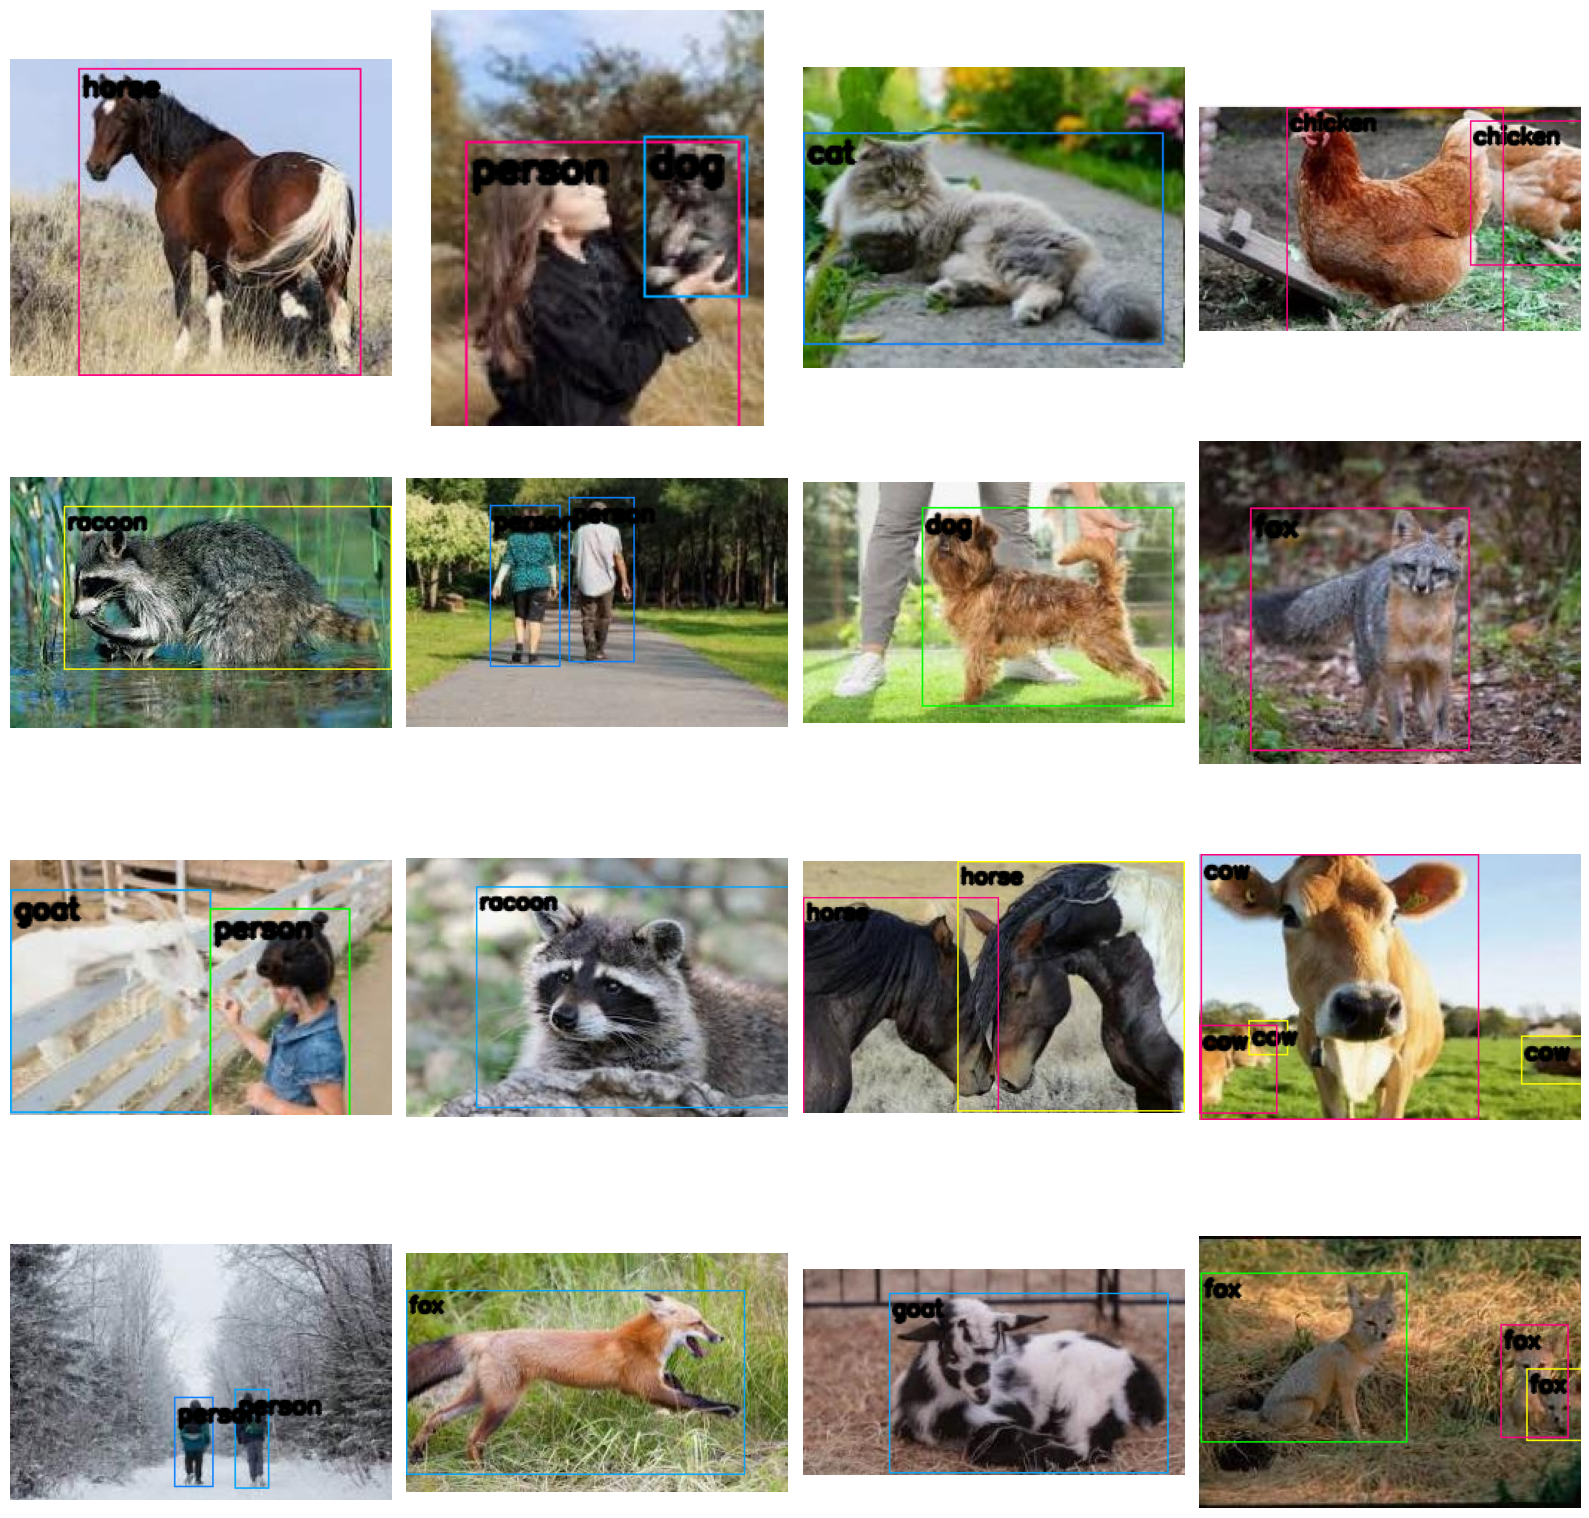

In [ ]:
import matplotlib.pyplot as plt
import os
import random
import cv2

train_images_dir = 'Animal_Detection_Datasets/train/images'
train_labels_dir = 'Animal_Detection_Datasets/train/labels'

print(len(os.listdir(train_images_dir)))
print(len(os.listdir(train_labels_dir)))

cls_names = ['cat','chicken','cow','dog','fox','goat','horse','person','racoon','skunk']

color_sample = [
    (12, 128, 255),   # Orange-ish
    (255, 0, 127),    # Pink
    (0, 255, 0),      # Green
    (255, 255, 0),    # Cyan
    (0, 165, 255)     # Blue-ish
]

# Get list of test images (max 16)
image_files = os.listdir(train_images_dir)

# Plot settings
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.ravel()

for idx in range(16):
    img_name = random.choice(image_files)
    img_path = os.path.join(train_images_dir, img_name)

    label_name = f'{img_name[:-3]}txt'
    label_path = os.path.join(train_labels_dir, label_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw each box if confidence > 0.8
    with open(label_path, 'r') as f:
      for line in f:
        data = line.strip().split()

        cls_id = int(data[0])
        label = cls_names[cls_id]

        x_center = float(data[1])
        y_center = float(data[2])
        width = float(data[3])
        height = float(data[4])

        img_h, img_w = image.shape[:2]

        x1 = int((x_center - width / 2) * img_w)
        y1 = int((y_center - height / 2) * img_h)
        x2 = int((x_center + width / 2) * img_w)
        y2 = int((y_center + height / 2) * img_h)

        xyxy = [x1, y1, x2, y2]

        image = draw_boxes(image, xyxy, label, color_sample)

    # Plot
    ax[idx].imshow(image)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()


# **Install Ultralytics**

In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00


# **Train YOLOv10 Model on Animal Detection Dataset**


In [7]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model
model = YOLO('yolov10l.pt')  # 'yolov8s.pt' or 'yolov8m.pt' for better accuracy

# Train the model and save only the best checkpoint
model.train(
    data='Animal_Detection_Datasets/data.yaml',
    epochs=20,
    imgsz=640,
    batch=8,
    name='Animal_Detection_Datasets_yolov10',
    save=True,
    save_period=-1,  # Don't save every epoch
    patience=20,     # Early stopping if no improvement for 20 epochs (optional)
    val=True,     # Run validation during training to select best model


    # Data augmentation options
    degrees=10,        # Random rotation degrees
    translate=0.1,     # Random translation
    scale=0.5,         # Random scale
    shear=2.0,         # Random shear
    perspective=0.0005,# Perspective transform
    flipud=0.5,        # Vertical flip probability
    fliplr=0.5,        # Horizontal flip probability
    mosaic=1.0,        # Mosaic augmentation
    mixup=0.2,         # MixUp augmentation
    hsv_h=0.015,       # Hue augmentation
    hsv_s=0.7,         # Saturation augmentation
    hsv_v=0.4          # Value augmentation
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Animal_Detection_Datasets/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ke

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7889ea4bfaa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

# **Plot Training Metrics (Loss and Accuracy)**


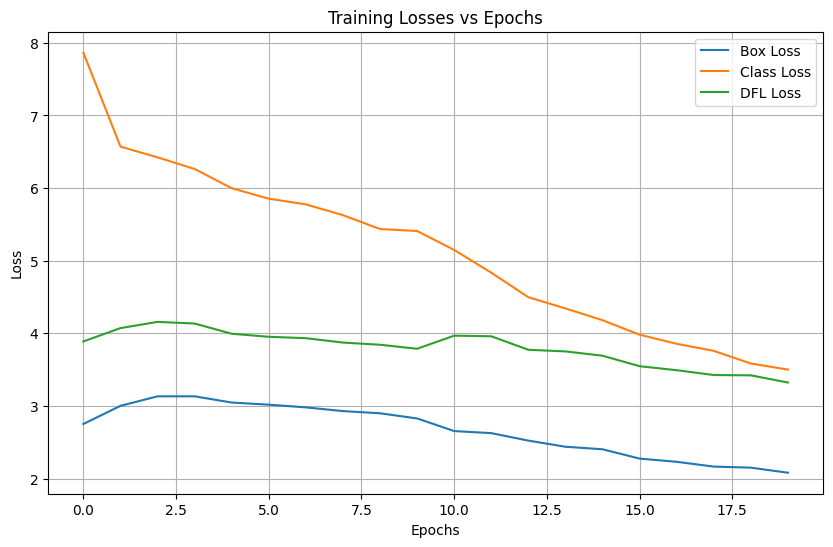

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to results.csv
results_path = "runs/detect/Animal_Detection_Datasets_yolov10/results.csv"

# Load results
df = pd.read_csv(results_path)

# Clean column names
df.columns = df.columns.str.strip()

# ----------------------------
# Plot Training Losses
# ----------------------------
plt.figure(figsize=(10, 6))
plt.plot(df["train/box_loss"], label="Box Loss")
plt.plot(df["train/cls_loss"], label="Class Loss")
plt.plot(df["train/dfl_loss"], label="DFL Loss")
plt.title("Training Losses vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# **Visualize YOLOv10 Model Predictions on Test Images**



0: 448x640 1 racoon, 50.9ms
Speed: 2.0ms preprocess, 50.9ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 1 goat, 1 skunk, 50.6ms
Speed: 1.9ms preprocess, 50.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 34.1ms
Speed: 1.7ms preprocess, 34.1ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 (no detections), 33.4ms
Speed: 1.5ms preprocess, 33.4ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)

0: 512x640 (no detections), 49.0ms
Speed: 1.9ms preprocess, 49.0ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 640)

0: 480x640 3 skunks, 29.0ms
Speed: 1.7ms preprocess, 29.0ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 608x640 1 goat, 49.2ms
Speed: 2.3ms preprocess, 49.2ms inference, 0.4ms postprocess per image at shape (1, 3, 608, 640)

0: 320x640 (no detections), 47.8ms
Speed: 2.1ms preprocess, 47.8ms inference, 0.3ms postpro

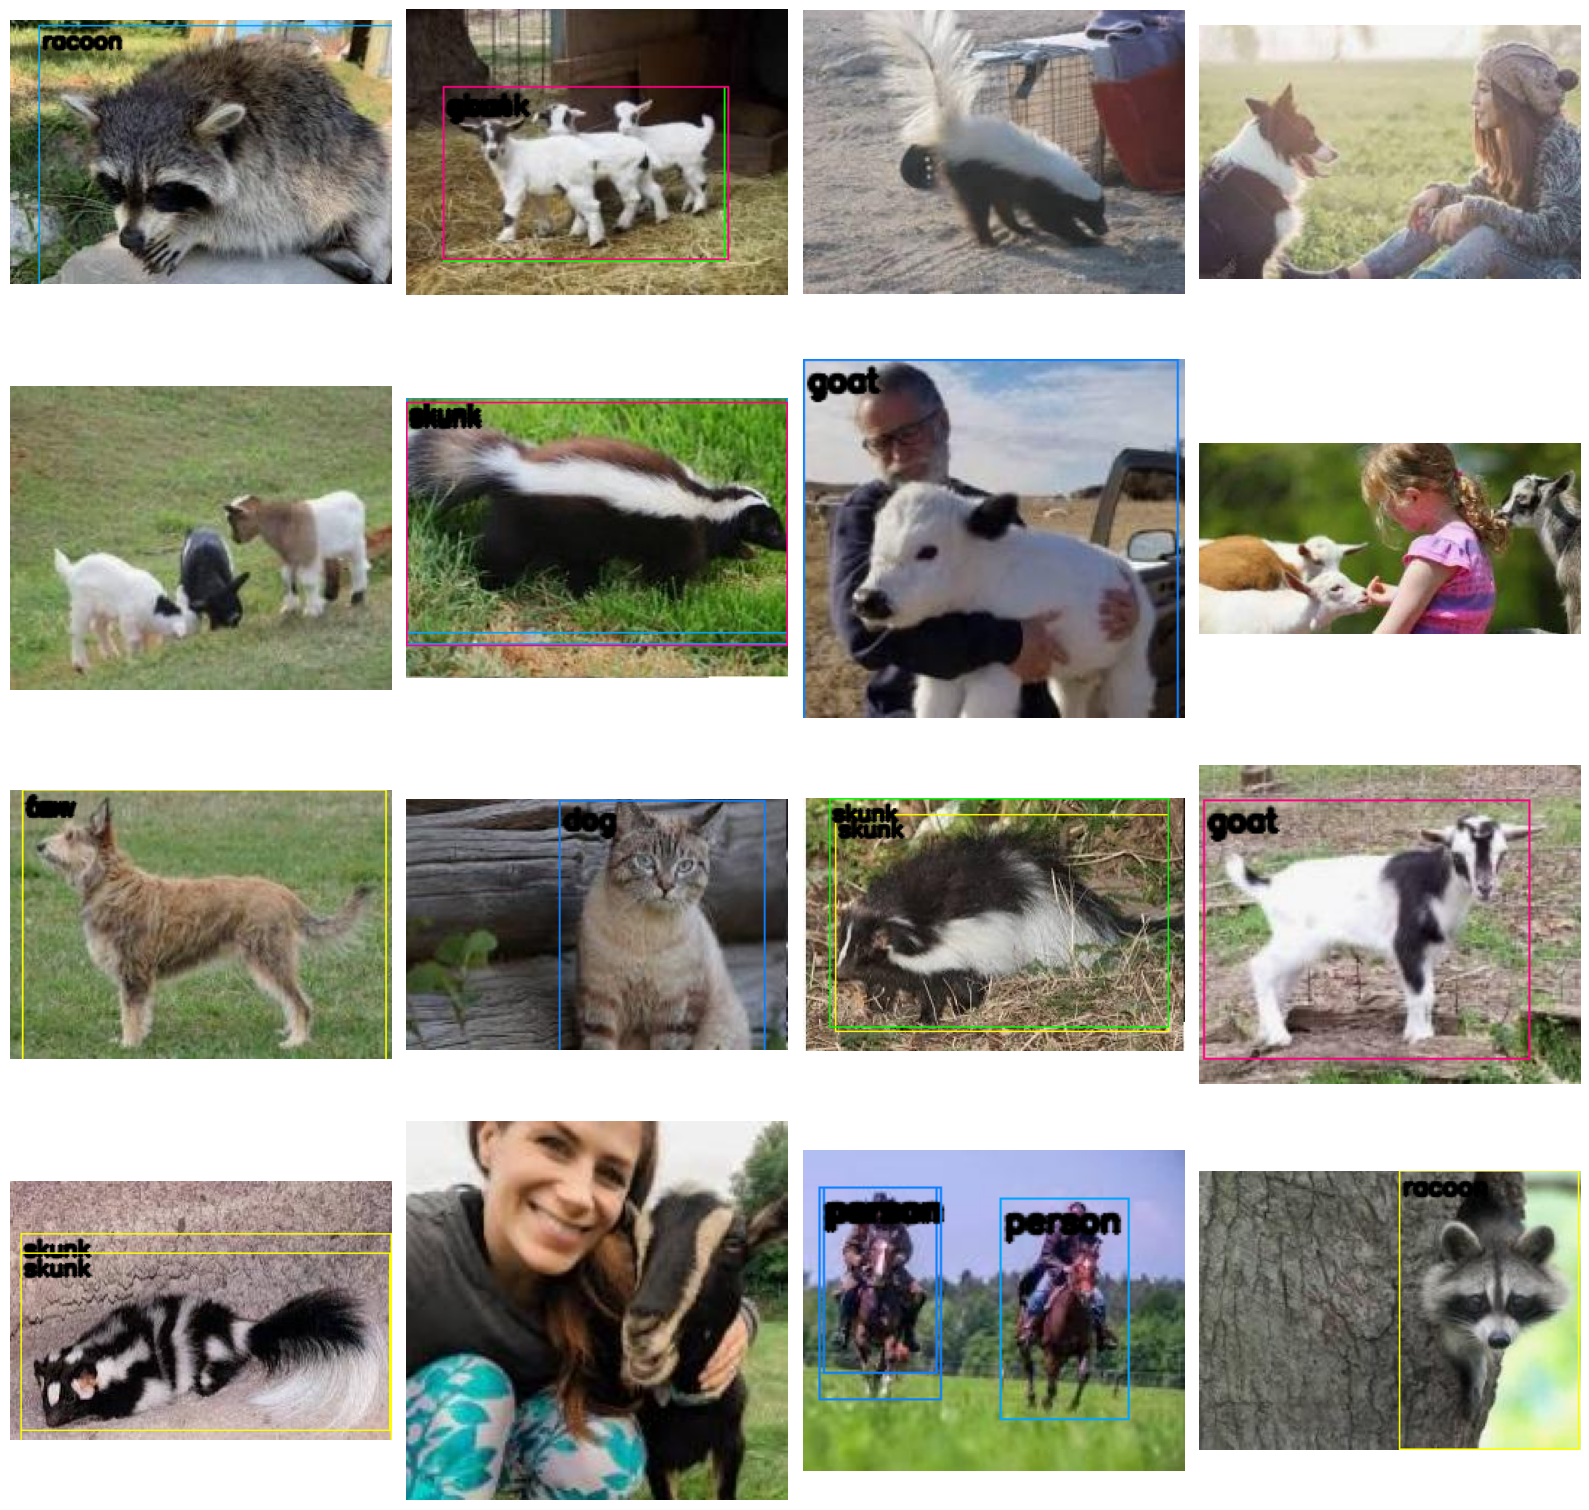

In [13]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# Load trained model
model = YOLO('runs/detect/Animal_Detection_Datasets_yolov10/weights/best.pt')

# Test images directory
test_images_dir = 'Animal_Detection_Datasets/test/images'

color_sample = [
    (12, 128, 255),   # Orange-ish
    (255, 0, 127),    # Pink
    (0, 255, 0),      # Green
    (255, 255, 0),    # Cyan
    (0, 165, 255)     # Blue-ish
]

# Get list of test images (max 16)
image_files = os.listdir(test_images_dir)

# Plot settings
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.ravel()

for idx in range(16):
    img_name = random.choice(image_files)
    img_path = os.path.join(test_images_dir, img_name)
    image = Image.open(img_path)

    # Inference
    results = model(image)[0]  # Get first result (one image)

    image = np.array(image)

    # Draw each box if confidence > 0.8
    for box in results.boxes:

        xyxy = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        image = draw_boxes(image, xyxy, label, color_sample)

    # Plot
    ax[idx].imshow(image)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()
